**MOST RECENT VERSION OF THIS FILE, CHECK GITHUB FOR PROGRESS!!**

In [44]:
import symlib

import matplotlib
import matplotlib.pyplot as plt
from matplotlib import colormaps
from matplotlib.lines import Line2D
import matplotlib.colors as mcolors

import numpy as np
import os

import scipy
from scipy import stats
from scipy.optimize import curve_fit
from scipy.stats import linregress

Loading host 39 in suite SymphonyLMC
Loading host 45 in suite SymphonyMilkyWay
Loading host 20 in suite MWest
Loading host 49 in suite SymphonyGroup
Loading host 33 in suite SymphonyLCluster
Loading host 81 in suite SymphonyCluster


C:\Users\steph\AppData\Local\Temp\ipykernel_3172\620365721.py:156: RuntimeWarning: Mean of empty slice
  mean = np.nanmean(masses, axis = 0)              # (T,)
C:\Users\steph\AppData\Local\Temp\ipykernel_3172\620365721.py:157: RuntimeWarning: All-NaN slice encountered
  median = np.nanmedian(masses, axis = 0)          # (T,)
C:\Users\steph\miniconda3\envs\dm-analysis-env\lib\site-packages\numpy\lib\_nanfunctions_impl.py:2019: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
C:\Users\steph\miniconda3\envs\dm-analysis-env\lib\site-packages\numpy\lib\_nanfunctions_impl.py:1620: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,
C:\Users\steph\AppData\Local\Temp\ipykernel_3172\620365721.py:274: RuntimeWarning: Mean of empty slice
  norm_mean   = np.nanmean(norm_masses, axis = 0)


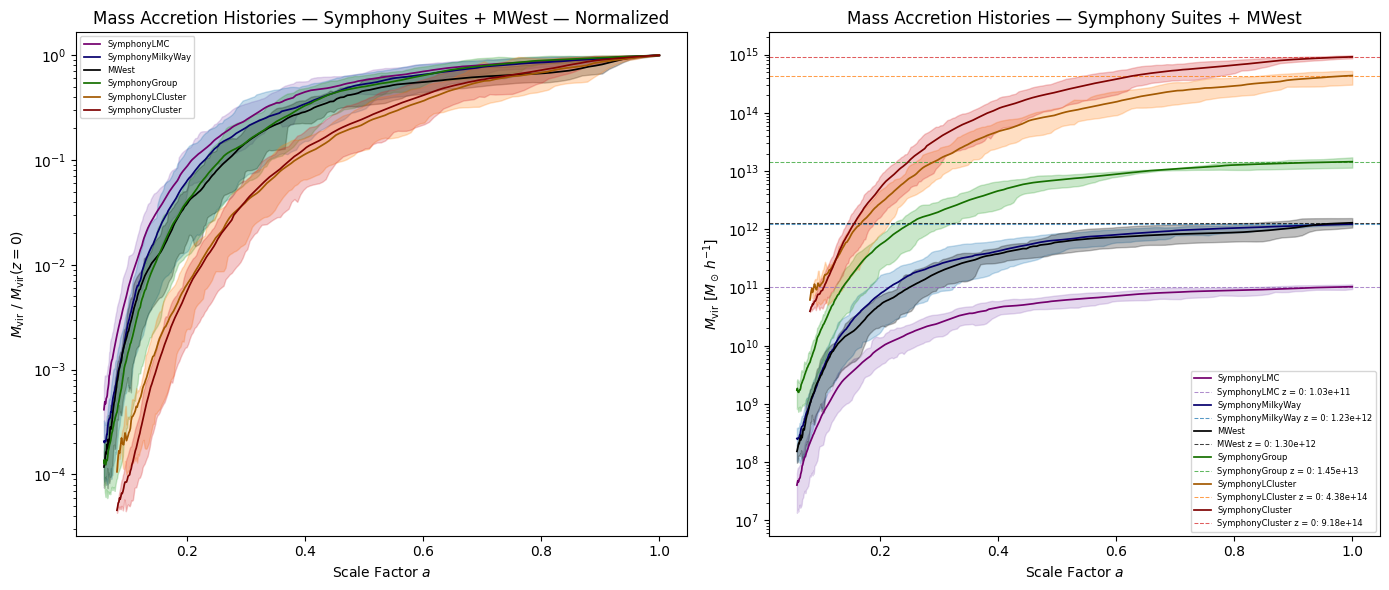

In [96]:
## MAHs dataloader
## reading in data for creating MAHs for all suites in Symphony (+MWest, +EDEN eventually)
## inputs:
## 1. base_dir = base directory (main folder where Symphony suites are stored)
## 2. suite_list = list of Symphony suites whose data is being read in (strings must match folder filenames --> will add functionality to check this later)

## output will be a dictionary, with indexable (key, value) pairs
## the dataloader function will be built on a per-suite basis for simplicity

## GLOBALS:
base_dir = "C:/Users/steph/Symphony"
suite_list: list[str] = ["SymphonyLMC", "SymphonyMilkyWay", "MWest", "SymphonyGroup", "SymphonyLCluster", "SymphonyCluster"]
colors: dict[str, str] = {
    "SymphonyLMC": "tab:purple",
    "SymphonyMilkyWay": "tab:blue",
    "MWest": "black",
    "SymphonyGroup": "tab:green",
    "SymphonyLCluster": "tab:orange",
    "SymphonyCluster": "tab:red"}
avg_colors: dict[str, tuple[float, float, float]] = {
    "SymphonyLMC": (102/225, 0/255, 110/255),
    "SymphonyMilkyWay": (7/255, 0/255, 110/255),
    "MWest": (0, 0, 0),
    "SymphonyGroup": (22/255, 112/255, 0/255),
    "SymphonyLCluster": (163/255, 90/255, 2/255),
    "SymphonyCluster": (128/255, 3/255, 3/255)}

min_particles: int = 300                                 ## minimum # of particles for a halo to be considered "well-resolved"
z_max: float = 16.0                                      ## maximum redshift to keep (inclusive)


## HELPER FUNCTIONS:

## build_z_mask returns a numpy array of timesteps we want to keep
def build_z_mask(scale_factors: np.ndarray, suite: str):
    
    redshifts = (1.0 / scale_factors) - 1.0
    mask = redshifts <= z_max
    if suite == "MWest":
        ## MWest behavior is different for some reason?
        mask &= scale_factors <= 1.0
        
    return mask

## due to the masking, lists may be different sizes
## so we need to pad the shorter arrays with NaN until they all match the length of the longest one
## nan_padding returns a numpy array of left-padded so that all are the same length as the longest array,
## then stacks them into a 2D array with shape (n_arrays, length)
## left-padding aligns all the arrays at their z = 0 snapshot
def nan_padding(arrays: list[np.ndarray], length: int):
    
    padded = [np.concatenate([np.full(length - len(a), np.nan), a]) for a in arrays]
    
    return np.vstack(padded)
    
## per-suite dataloader; loads mass accretion history information for every host in a given suite
## inputs: base_dir (string), suite (string),
##         min_mass_resolution_limit (int, usually 300 particles), z_max (float, this is somewhat arbitrarily chosen),
##         verbose (bool, controls whether progress print statements are on or off)
## outputs dict with keys:
##         scale_factors        # np.ndarray, shape (T,)   – reference time axis
##         redshifts            # np.ndarray, shape (T,)
##         masses               # np.ndarray, shape (N, T)  – NaN where unresolved
##         host_scale_factors   # list[np.ndarray]       – per-host, unpadded
##         host_masses          # list[np.ndarray]       – per-host, unpadded
##         particle_mass        # float  – mp [M_sun/h] from first host
##         n_hosts              # int
##         suite                # str

def load_mah_suite_data(base_dir: str, suite: str, min_particles: int = min_particles, z_max: float = z_max, verbose: bool = True):
        
    n_hosts = symlib.n_hosts(suite)                 ## get the # of hosts (individual simulations in each folder)

    ## initializing empty lists to be filled later
    host_masses: list[np.ndarray] = []
    host_scale_factors: list[np.ndarray] = []
    particle_mass = None

    ## looping over hosts in a particular suite
    for i_host in range(n_hosts):
        if verbose:
            print(f"Loading host {i_host + 1} in suite {suite}", end = "\r", flush = True)
            
        sim_dir = symlib.get_host_directory(base_dir, suite, i_host)                ## getting the full directory to the host data
        h, hist = symlib.read_subhalos(sim_dir)                                     ## reading in the Symfind halo finder data

        ## storing particle mass for the first host (identical across a suite)
        if particle_mass is None:
            params = symlib.simulation_parameters(sim_dir)                          ## getting simulation parameters used in this suite
            particle_mass = float(params["mp"])                                     ## getting "macro-particle" mass used in this suite

        scale_factors = symlib.scale_factors(sim_dir)                               ## reading in per-host scale factors (resolves problems with masking)
        z_mask = build_z_mask(scale_factors, suite)
        scale_factors = scale_factors[z_mask]                                       ## applying the redshift cut

        ## getting host properties (host is always index 0)
        host_mass = np.array(h["mvir"][0])                                          ## host virial mass for all snapshots
        host_ok = np.array(h["ok"][0])                                              ## all snapshots where the host was properly identified by Symfind
        mass_cut = min_particles * particle_mass                                    ## 300 particles mass resolution limit

        ## applying the 300 particle resolution cut and the "ok" survival cut:
        ## keeping only snapshots where the host is "ok" AND "well-resolved" (at or above 300 particles)
        ## host_mass_masked *removes* these subhalos by replacing them with NaN
        host_mass_masked = np.where((host_mass < mass_cut) | ~host_ok, np.nan, host_mass)[z_mask]
        host_masses.append(host_mass_masked)
        host_scale_factors.append(scale_factors)

    if verbose:
        print()

    ## use the host with the most snapshots as the reference time axis:
    ref_idx = int(np.argmax([len(s) for s in host_scale_factors]))
    ref_scale = host_scale_factors[ref_idx]
    max_len = len(ref_scale)
    masses_2D = nan_padding(host_masses, max_len)
    ref_redshift = (1.0 / ref_scale) - 1.0

    return {"suite": suite,
            "n_hosts": n_hosts,
            "particle_mass": particle_mass,
            "scale_factors": ref_scale,               ## shape (T, )
            "redshifts": ref_redshift,              ## shape (T, )
            "masses": masses_2D,                      ## shape (N, T)
            "host_scale_factors": host_scale_factors, ## shape (N, T)
            "host_masses": host_masses}


## function to automatically load all suites in suite_list, using load_mah_suite_data:
def load_all_MAH_data(base_dir: str, suites = list[str], min_particles: int = min_particles, z_max: float = z_max, verbose: bool = True):
    
    if suites is None:
        suites = suite_list   ## defaults to the global string

    all_data: dict[str, dict] = {}
    
    for index, suite in enumerate(suites):
        all_data[suite] = load_mah_suite_data(base_dir, suite, min_particles = min_particles, z_max = z_max, verbose = verbose)
        
    return all_data


## statistics + plotter (Symphony Figure 5 style)

## STATISTICS --> computes mean and 16-84% confidence band
def compute_MAH_stats(suite_data: dict):

    masses = suite_data["masses"]                    # (N, T)
    scale_factors = suite_data["scale_factors"]      # (T,)
    redshifts = suite_data["redshifts"]              # (T,)

    ## check that at least one host is well resolved at a particular timestep:
    n_resolved = np.sum(~np.isnan(masses), axis = 0) # (T,)         ## ~np.isnan gives all where the value is NOT NaN
    valid_mask = n_resolved > 0                      # (T,) bool

    ## using nan-sensitive functions
    mean = np.nanmean(masses, axis = 0)              # (T,)
    median = np.nanmedian(masses, axis = 0)          # (T,)
    std = np.nanstd(masses, axis = 0)                # (T,)
    p16 = np.nanpercentile(masses, 16, axis = 0)     # (T,)
    p84 = np.nanpercentile(masses, 84, axis = 0)     # (T,)

    # use the last snapshot where at least one host is resolved,
    # rather than blindly taking index [-1] which may be all-NaN.
    valid_indices = np.where(valid_mask)[0]
    final_mass = float(mean[valid_indices[-1]]) if len(valid_indices) > 0 else np.nan

    return {"suite": suite_data["suite"],
            "scale_factors": scale_factors,
            "redshifts": redshifts,
            "mean": mean,
            "median": median,
            "std": std,
            "p16": p16,
            "p84": p84,
            "final_mass": final_mass,
            "valid_mask": valid_mask,
            "n_resolved": n_resolved}

## function to run the statistics over all suites
def compute_all_MAH_stats(all_data: dict[str, dict]):
    all_stats = {suite: compute_MAH_stats(suite_data) for suite, suite_data in all_data.items()}
    return all_stats


## MAIN PLOTTER:
## globals:
redshift_ticks = [16, 8, 4, 2, 1, 0.5, 0.25]
redshift_labels = ["16", "8", "4", "2", "1", "0.5", "0.25"]
z_xlim = (16.0, 0.05)
host_lw = 0.5
host_alpha = 0.33
avg_lw = 1.25
confidence_band_alpha = 0.25

## plotting helpers:

## getting the correct x-axis
def get_xaxis(suite_stats: dict, x_axis: str):
    
    if x_axis == "scale_factor":
        return suite_stats["scale_factors"]
    elif x_axis == "redshift":
        return suite_stats["redshifts"]
    else:
        raise ValueError(f"x_axis must be 'scale_factor' or 'redshift', but got {x_axis!r}")

## configuring axes
def ax_config(ax: matplotlib.axes.Axes, x_axis: str):
    
    ax.set_yscale("log")
    ax.set_ylabel(r"$M_\mathrm{vir}\ [M_\odot\,h^{-1}]$", fontsize = 10)

    if x_axis == "scale_factor":
        ax.set_xlabel("Scale Factor $a$", fontsize = 10)

    elif x_axis == "redshift":
        ax.set_xscale("log")
        ax.set_xticks(redshift_ticks)
        ax.set_xticklabels(redshift_labels)
        ax.set_xlim(z_xlim)
        ax.set_xlabel(r"Redshift $z$", fontsize = 10)

## plotting per-suite data:
def plot_suite_MAH(ax: matplotlib.axes.Axes, suite: str, suite_data: dict, suite_stats: dict, x_axis: str,
                   show_hosts: bool = True, show_confidence: bool = True):

    color = colors[suite]
    avg_color = avg_colors[suite]
    valid = suite_stats["valid_mask"]
    x = get_xaxis(suite_stats, x_axis)

    ## individual hosts:
    if show_hosts:
        for host_sf, host_mass in zip(suite_data["host_scale_factors"], suite_data["host_masses"]):

            ## each host has its own time axis:
            host_x = host_sf if x_axis == "scale_factor" else ((1.0 / host_sf) - 1.0)
            ax.plot(host_x, host_mass, color = color, lw = host_lw, alpha = host_alpha)

    ## 16-84% confidence band:
    if show_confidence:
        ax.fill_between(x[valid], suite_stats["p16"][valid], suite_stats["p84"][valid], color = color, alpha = confidence_band_alpha)

    ## mean:
    ax.plot(x[valid], suite_stats["mean"][valid], color = avg_color, lw = avg_lw, zorder = 3, label = suite)

    ## final mass line:
    fm = suite_stats["final_mass"]
    if np.isfinite(fm):
        ax.axhline(fm, color = colors[suite], linestyle = "--", lw = 0.75, alpha = 0.75, label = f"z = 0 mass: {fm:.2e}")


## adding the option to normalize by the z = 0 mass accretion history:

## computing z = 0 normalized masses:
def compute_normalized_masses(suite_data: dict):
    
    masses = suite_data["masses"].copy()
    z0_masses = masses[:, -1]
    norm_masses = masses / z0_masses[:, np.newaxis]

    return norm_masses

def plot_suite_MAH_normalized(ax: matplotlib.axes.Axes, suite: str, suite_data: dict, suite_stats: dict, x_axis: str,
                              show_hosts: bool, show_confidence: bool = True):

    color = colors[suite]
    avg_color = avg_colors[suite]
    valid = suite_stats["valid_mask"]
    x = get_xaxis(suite_stats, x_axis)
    fm = suite_stats["final_mass"]

    norm_masses = compute_normalized_masses(suite_data)
    norm_mean   = np.nanmean(norm_masses, axis = 0)
    norm_p16    = np.nanpercentile(norm_masses, 16, axis = 0)
    norm_p84    = np.nanpercentile(norm_masses, 84, axis = 0)

    ## individual hosts normalized by their own z=0 mass:
    if show_hosts:
        for host_sf, host_mass in zip(suite_data["host_scale_factors"], suite_data["host_masses"]):
            host_x  = host_sf if x_axis == "scale_factor" else ((1.0 / host_sf) - 1.0)
            host_fm = host_mass[-1]
            if np.isfinite(host_fm) and host_fm != 0:
                ax.plot(host_x, host_mass / host_fm, color = color, lw = host_lw, alpha = host_alpha)

    if show_confidence:
        ax.fill_between(x[valid], norm_p16[valid], norm_p84[valid], color = color, alpha = confidence_band_alpha)
    ax.plot(x[valid], norm_mean[valid], color = avg_color, lw = avg_lw, zorder = 3, label = suite)

## putting it all together:
## all_data = data dictionary from load_all_MAH_data
## all_stats = data dictionary from compute_all_MAH_stats
## outputs a single-panel figure

def plot_all_MAH(all_data: dict[str, dict], all_stats: dict[str, dict], suites: list[str],
                 x_axis: str = "scale_factor", show_hosts: bool = True, dual: bool = False, show_confidence: bool = False,
                 figsize_single: tuple[float, float] = (7, 6), figsize_dual: tuple[float, float] = (14, 6),
                 title: str = "Mass Accretion Histories — Symphony Suites + MWest"):

    if suites is None:
        suites = [s for s in suite_list if s in all_data]

    figsize = figsize_dual if dual else figsize_single
    ncols = 2 if dual else 1
    fig, axes = plt.subplots(ncols = ncols, figsize = figsize)
    ax_main = axes[1] if dual else None
    ax_norm = axes[0] if dual else axes

    for suite in suites:
        plot_suite_MAH(ax_main, suite, all_data[suite], all_stats[suite], x_axis = x_axis, show_hosts = show_hosts, show_confidence = show_confidence)

        if dual:
            plot_suite_MAH_normalized(ax_norm, suite, all_data[suite], all_stats[suite], x_axis = x_axis, show_hosts = show_hosts, show_confidence = show_confidence)

    ax_config(ax_main, x_axis)
    
    if dual:
        ax_config(ax_norm, x_axis)
        #ax_norm.set_yscale("linear")
        ax_norm.set_ylabel(r"$M_\mathrm{vir}\ /\ M_\mathrm{vir}(z{=}0)$", fontsize = 10)

    legend_handles = []
    for s in suites:
        legend_handles.append(Line2D([0], [0], color = avg_colors[s], lw = avg_lw, label = s))
        if np.isfinite(all_stats[s]["final_mass"]):
            legend_handles.append(Line2D([0], [0], color = colors[s], lw = 0.75, alpha = 0.75, linestyle = "--",
                                         label = f"{s} z = 0: {all_stats[s]['final_mass']:.2e}"))
            
    ax_main.legend(handles = legend_handles, loc = "best", fontsize = 6)
    ax_main.set_title(title, fontsize = 12)

    if dual:
        ## normalized panel only needs suite name labels, no final mass lines
        norm_handles = [Line2D([0], [0], color = avg_colors[s], lw = avg_lw, label = s) for s in suites]
        ax_norm.legend(handles = norm_handles, loc = "best", fontsize = 6)
        ax_norm.set_title(f"{title} — Normalized", fontsize = 12)

    
    fig.tight_layout()

    return fig, axes




data = load_all_MAH_data(base_dir, suite_list)
stats = compute_all_MAH_stats(data)
fig, axes = plot_all_MAH(data, stats, suite_list, x_axis = "scale_factor", show_hosts = False, dual = True, show_confidence = True)

fig.savefig(f"MAHs for all Symphony suites + MWest 3", dpi = 250, bbox_inches = "tight")
plt.show()

In [69]:
## want to make a script that performs a linear fit to the SHMF and returns the slope

base_dir = "C:/Users/steph/Symphony"
#suite_list = ["MWest", "SymphonyLMC", "SymphonyMilkyWay", "SymphonyGroup", "SymphonyLCluster", "SymphonyCluster"]
#redshifts = [0, 0.1, 0.5, 1.0, 2.0]
colors = ["tab:purple", "tab:blue", "black", "tab:green", "tab:orange", "tab:red"]

suite_list = ["SymphonyLMC"]
redshifts = [2.0, 0.0]

def shmf_arbz_dataloader(base_dir, suite_list, redshifts, colors):

    shmf_data = {}

    ## loop over redshifts:
    for z_index, target_z in enumerate(redshifts):

        print(f"Starting redshift {target_z}")

        a_target = 1/(1 + target_z)

        for suite_index, suite_name in enumerate(suite_list):

            print(f"Current suite: {suite_name}")
                  
            n_hosts = symlib.n_hosts(suite_name)

            # create histogram bins
            params = symlib.simulation_parameters(suite_name)
            m_min = 300 * params["mp"]         # minimum of 300 particles
            m_max = 1e15
            n_bins = 149
            bins = 10**np.linspace(np.log10(m_min), np.log10(m_max), n_bins + 1)
            mass_bins = np.sqrt(bins[:-1] * bins[1:])  ## saving bin centers instead of left edges

            ## save per-host SHMF
            host_shmfs = []

            for i_host in range(n_hosts):
                sim_dir = symlib.get_host_directory(base_dir, suite_name, i_host)
                print(f"Current host: {sim_dir}")
                
                scale_factors = symlib.scale_factors(sim_dir)
                snap_index = np.argmin(np.abs(scale_factors - a_target))

                h, hist = symlib.read_subhalos(sim_dir)

                # figure out which subhalos exist within the virial radius of the host halo at a given snapshot
                r = np.sqrt(np.sum(h["x"][:, snap_index]**2, axis = 1))          # calculate the subhalo's distance
                host_rvir = h["rvir"][0, snap_index]                             # get the virial radius of the host halo
                ok = h["ok"][:, snap_index] & (r < host_rvir)                    # only keep the halo if it's been okayed and inside the virial radius
                n_vir, _ = np.histogram(hist["mpeak"][ok][1:], bins = bins)      # add to histogram
                N_vir = np.cumsum(n_vir[::-1])[::-1]                             # cumulative histogram
                host_shmfs.append(N_vir)
            
            host_shmfs = np.array(host_shmfs)
            host_shmfs = host_shmfs[host_shmfs > 0]  # shape: (n_hosts, n_bins)

            
            ## computing statistics:
            #shmf_mean = np.mean(host_shmfs, axis = 0)
            #shmf_p16 = np.percentile(host_shmfs, 16, axis = 0)
            #shmf_p84 = np.percentile(host_shmfs, 84, axis = 0)
            
            print(f"Accumulation finished for suite: {suite_name} at redshift {target_z}")
            shmf_data[(suite_name, target_z)] = {
                "suite_list": suite_list,
                "redshifts": redshifts,
                "mass_bins": mass_bins,
                #"shmf_mean": shmf_mean,
                #"shmf_p16": shmf_p16,
                #"shmf_p84": shmf_p84,
                "colors": colors[suite_index]}

    return shmf_data

In [70]:
shmf_data = shmf_arbz_dataloader(base_dir, suite_list, redshifts, colors)

Starting redshift 2.0
Current suite: SymphonyLMC
Current host: C:/Users/steph/Symphony\SymphonyLMC\Halo032
Current host: C:/Users/steph/Symphony\SymphonyLMC\Halo059
Current host: C:/Users/steph/Symphony\SymphonyLMC\Halo0662
Current host: C:/Users/steph/Symphony\SymphonyLMC\Halo083
Current host: C:/Users/steph/Symphony\SymphonyLMC\Halo088
Current host: C:/Users/steph/Symphony\SymphonyLMC\Halo097
Current host: C:/Users/steph/Symphony\SymphonyLMC\Halo104
Current host: C:/Users/steph/Symphony\SymphonyLMC\Halo110
Current host: C:/Users/steph/Symphony\SymphonyLMC\Halo202
Current host: C:/Users/steph/Symphony\SymphonyLMC\Halo208
Current host: C:/Users/steph/Symphony\SymphonyLMC\Halo218
Current host: C:/Users/steph/Symphony\SymphonyLMC\Halo296
Current host: C:/Users/steph/Symphony\SymphonyLMC\Halo301
Current host: C:/Users/steph/Symphony\SymphonyLMC\Halo303
Current host: C:/Users/steph/Symphony\SymphonyLMC\Halo340
Current host: C:/Users/steph/Symphony\SymphonyLMC\Halo374
Current host: C:/Users

In [67]:



## config:
base_dir = 

# Number of bins for the mass function histogram
n_bins = 30

#####################################################################################################
## helper functions:

## convert redshift to scale factor (a = 1/1+z)
def redshift_to_scale(z):
    return 1.0 / (1.0 + z)

## return the snapshot index closes to a particular target scale factor
def nearest_snapshot(scale_factors, target_a):
    return int(np.argmin(np.abs(scale_factors - target_a)))

## power-law fit ~ M^alpha  via log-log linear regression.
## returns slope, intercept, r_value, fit_x, fit_y.
## returns None for all if fewer than 2 valid bins exist in the range.
#def log_log_fit(bin_centers, shmf, log_mass_min, log_mass_max):
    
#    mask = ((shmf > 0) & (bin_centers >= log_mass_min) & (bin_centers <= log_mass_max))
#    x = bin_centers[mask]
#    y = np.log10(shmf[mask])

#    slope, intercept, r_value, _, _ = linregress(x, y)
#    fit_x = np.linspace(x.min(), x.max(), 200)
#    fit_y = 10 ** (slope * fit_x + intercept)

#    return slope, intercept, r_value, fit_x, fit_y

######################################################################################################

## PLOTTING:

## multi-panel SHMF
## each panel shows all suites with per-suite, redshift-scaled fit ranges
## 1. get shmf data
## 2. fit a power law
## 3. plot + print slope
## parameters: base_dir, suites, n_bins, fit, upper and lower bounds for fit, output filename
def plot_shmf_redshifts(base_dir, suite_list, shmf_data, n_bins = n_bins, save_path = "shmf.png"):
    
    n_panels = len(redshifts)
    fig, axes = plt.subplots(1, n_panels, figsize = (4.5 * n_panels, 5.5), sharey = False)
 
    # header
    print(f"{'Suite':<12} {'z':>5} {'z_actual':>9}, {'Fit range':>18} {'Slope':>8} {'R²':>7}")
    print("-" * 65)
 
    # Legend handles collected from the first panel only
    legend_handles = []

    for col, target_z in enumerate(redshifts):
        ax = axes[col]

        for suite in suite_list:
            print(suite, target_z)
            #colors = shmf_data[(suite, target_z)["colors"]]
 
            # 1. get mass function
            #bin_centers = shmf_data[(suite, target_z)]
            

            '''
            # collect legend handle once (first panel)
            if col == 0:
                pts.set_label(suite)
                legend_handles.append(pts)
 
            ax.axvspan(log_mass_min, log_mass_max, alpha = 0.04, color = color)
 
        ax.set_yscale("log")
        ax.set_xlabel(r"$\log_{10}(M_{\rm vir}\ [M_\odot/h])$", fontsize = 11)
        ax.set_title(f"$z = {target_z:.1f}$", fontsize = 12)
        ax.grid(True, which = "both", ls = ":", alpha = 0.4)
 
        if col == 0:
            ax.set_ylabel(r"$dN/d\log_{10}M$", fontsize = 11)
 
    # Single shared legend on the leftmost panel
    axes[0].legend(handles = legend_handles, fontsize = 8,
                   framealpha = 0.5, loc = "upper right")
 
    fig.suptitle("SHMF", fontsize = 13, y = 1.01)
    plt.tight_layout()
    plt.savefig(save_path, dpi = 150, bbox_inches = "tight")
    plt.show()
    print(f"\nFigure saved to: {save_path}")
 
 
## entry point:
if __name__ == "__main__":
    plot_shmf_redshifts()


'''

Suite            z  z_actual,          Fit range    Slope      R²
-----------------------------------------------------------------
SymphonyLMC 2.0
SymphonyMilkyWay 2.0
MWest 2.0
SymphonyGroup 2.0
SymphonyLCluster 2.0
SymphonyCluster 2.0
SymphonyLMC 0.0
SymphonyMilkyWay 0.0
MWest 0.0
SymphonyGroup 0.0
SymphonyLCluster 0.0
SymphonyCluster 0.0


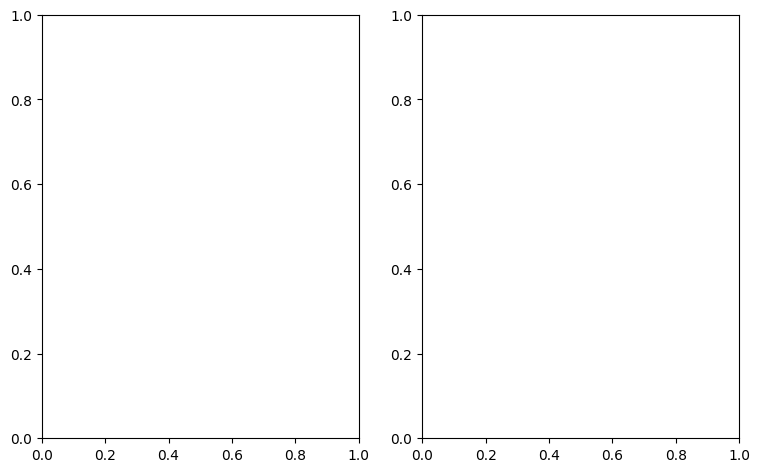

In [68]:
plot_shmf_redshifts(base_dir, suite_list, shmf_data)

0 0
All Objects Populated!
Saved!
1 5
All Objects Populated!
Saved!
2 10
All Objects Populated!
Saved!
3 15
All Objects Populated!
Saved!
4 20
All Objects Populated!
Saved!
5 25
All Objects Populated!
Saved!
6 30
All Objects Populated!
Saved!
7 35
All Objects Populated!
Saved!
8 40
All Objects Populated!
Saved!
9 45
All Objects Populated!
Saved!
10 50
All Objects Populated!
Saved!
11 55
All Objects Populated!
Saved!
12 60
All Objects Populated!
Saved!
13 65
All Objects Populated!
Saved!
14 70
All Objects Populated!
Saved!
15 75
All Objects Populated!
Saved!
16 80
All Objects Populated!
Saved!
17 85
All Objects Populated!
Saved!
18 90
All Objects Populated!
Saved!
19 95
All Objects Populated!
Saved!
20 100
All Objects Populated!
Saved!
21 105
All Objects Populated!
Saved!
22 110
All Objects Populated!
Saved!
23 115
All Objects Populated!
Saved!
24 120
All Objects Populated!
Saved!
25 125
All Objects Populated!
Saved!
26 130
All Objects Populated!
Saved!
27 135
All Objects Populated!
Sav

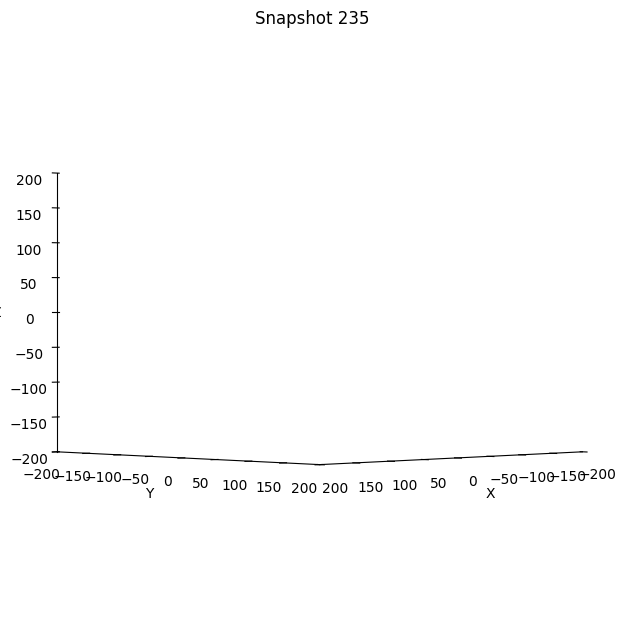

In [6]:
## GOAL: create a visualization that shows the behavior of subhalos in MWest over all snapshots
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.animation as animation

base_dir = "C:/Users/steph/Symphony"
suite_list = ["MWest"]

image_directory = "mwest_visual/*.png"   # where to look for images to turn into a GIF, and where to save the GIF
output_directory = "mwest_visual"
output_gif_path = "mwest_visual.gif"

## create a 3-D plot that we can rotate and manipulate later to see what's going on
fig = plt.figure(figsize = (7.5, 7.5))
ax = fig.add_subplot(111, projection='3d')

u = np.linspace(0, 2 * np.pi, 40)   # defining these rotation linspaces for later
v = np.linspace(0, np.pi, 20)

sphere_x = np.outer(np.cos(u), np.sin(v))
sphere_y = np.outer(np.sin(u), np.sin(v))
sphere_z = np.outer(np.ones_like(u), np.cos(v))

## now we need to read the location and virial radius data for every subhalo and plot it
for suite_index, suite in enumerate(suite_list):
    n_hosts = symlib.n_hosts(suite)

    host = "Halo113"

    sim_dir = symlib.get_host_directory(base_dir, suite, host)
    scale_factors = symlib.scale_factors(sim_dir)
    scale_factors = scale_factors[scale_factors <= 1]

    snapshots = np.arange(0, 240, 5)
        
    h, hist = symlib.read_subhalos(sim_dir)

    for snap_index, snap in enumerate(snapshots):
        print(snap_index, snap)
        
        filename = f"Snapshot {(snap):.2f}.png"
        full_path = os.path.join(output_directory, filename)

        host_rvir = h["rvir"][0, snap]
        host_mvir = h["mvir"][0, snap]
        host_pos = h["x"][0, snap]

        sub_rvir = h["rvir"][1:, snap]
        sub_pos = h["x"][1:, snap]
        
        ok1 = h["ok"][1:, snap]
        ok_sub_pos = sub_pos[ok1]
        ok_sub_rvir = sub_rvir[ok1]

        sub_dist = np.sqrt(np.sum(ok_sub_pos**2, axis=1))

        host_cx, host_cy, host_cz = host_center = host_pos[0], host_pos[1], host_pos[2]
        host_x = host_rvir * np.outer(np.cos(u), np.sin(v)) + host_cx
        host_y = host_rvir * np.outer(np.sin(u), np.sin(v)) + host_cy
        host_z = host_rvir * np.outer(np.ones(np.size(u)), np.cos(v)) + host_cz
        ax.plot_surface(host_x, host_y, host_z, color = "tab:purple",
                       rcount = 20, ccount = 20, shade = False, antialiased=False)

        for index, subhalo in enumerate(ok_sub_rvir):
            if (sub_dist[index] < host_rvir - ok_sub_rvir[index]):
                sub_cx, sub_cy, sub_cz = ok_sub_pos[index][0], ok_sub_pos[index][1], ok_sub_pos[index][2]
                sub_x = ok_sub_rvir[index] * sphere_x + sub_cx
                sub_y = ok_sub_rvir[index] * sphere_y + sub_cy
                sub_z = ok_sub_rvir[index] * sphere_z + sub_cz
                ax.plot_surface(sub_x, sub_y, sub_z, color = "tab:green",
                               rcount = 20, ccount = 20, shade = False, antialiased=False)
                

            elif (sub_dist[index] > host_rvir + ok_sub_rvir[index]):
                sub_cx, sub_cy, sub_cz = ok_sub_pos[index][0], ok_sub_pos[index][1], ok_sub_pos[index][2]
                sub_x = ok_sub_rvir[index] * sphere_x + sub_cx
                sub_y = ok_sub_rvir[index] * sphere_y + sub_cy
                sub_z = ok_sub_rvir[index] * sphere_z + sub_cz
                ax.plot_surface(sub_x, sub_y, sub_z, color = "tab:red",
                               rcount = 20, ccount = 20, shade = False, antialiased=False)

        ax.view_init(elev = 0, azim = 45)
        ax.set_xlim(-200, 200)
        ax.set_ylim(-200, 200)
        ax.set_zlim(-200, 200)
        ax.set_xlabel('X')
        ax.set_ylabel('Y')
        ax.set_zlabel('Z')
        ax.set_title(f"Snapshot {snap}")
    
        print("All Objects Populated!")
    
        plt.savefig(full_path, dpi = 80, facecolor = 'white')
        print("Saved!")

        ax.autoscale(enable=False)
        ax.grid(False)
        ax.xaxis.pane.set_visible(False)
        ax.yaxis.pane.set_visible(False)
        ax.zaxis.pane.set_visible(False)
        for coll in ax.collections[:]:
            coll.remove()

In [7]:
from matplotlib.animation import FuncAnimation, PillowWriter
from PIL import Image, ImageSequence
import glob
import re

pop_image_paths = sorted(glob.glob(image_directory), key=lambda x: int(re.search(r"(\d+)", x).group()))
 
# Load images 
images = []
for path in pop_image_paths:
    img = Image.open(path)
    images.append(img)

if images:
    images[0].save(output_gif_path, save_all=True, append_images=images[1:], duration = 100, loop=0)
    print(f"GIF created and saved at {output_gif_path}")
else:
    print("No images found in the specified directory.")

GIF created and saved at mwest_visual.gif


1 200
2 200
3 200
4 200
5 200
6 200
7 200
8 200
9 200
10 200
11 200
12 200
13 200
14 200
15 200
16 200
17 200
18 200
19 200
20 200
21 200
22 200
23 200
24 200
25 200
26 200
27 200
28 200
29 200
30 200
31 200
32 200
33 200
34 200
35 200
36 200
37 200
38 200
39 200
40 200
41 200
42 200
43 200
44 200
45 200
46 200
47 200
48 200
49 200
50 200
51 200
52 200
53 200
54 200
55 200
56 200
57 200
58 200
59 200
60 200
61 200
62 200
63 200
64 200
65 200
66 200
67 200
68 200
69 200
70 200
71 200
72 200
73 200
74 200
75 200
76 200
77 200
78 200
79 200
80 200
81 200
82 200
83 200
84 200
85 200
86 200
87 200
88 200
89 200
90 200
91 200
92 200
93 200
94 200
95 200
96 200
97 200
98 200
99 200
100 200
101 200
102 200
103 200
104 200
105 200
106 200
107 200
108 200
109 200
110 200
111 200
112 200
113 200
114 200
115 200
116 200
117 200
118 200
119 200
120 200
121 200
122 200
123 200
124 200
125 200
126 200
127 200
128 200
129 200
130 200
131 200
132 200
133 200
134 200
135 200
136 200
137 200
138 200
139 

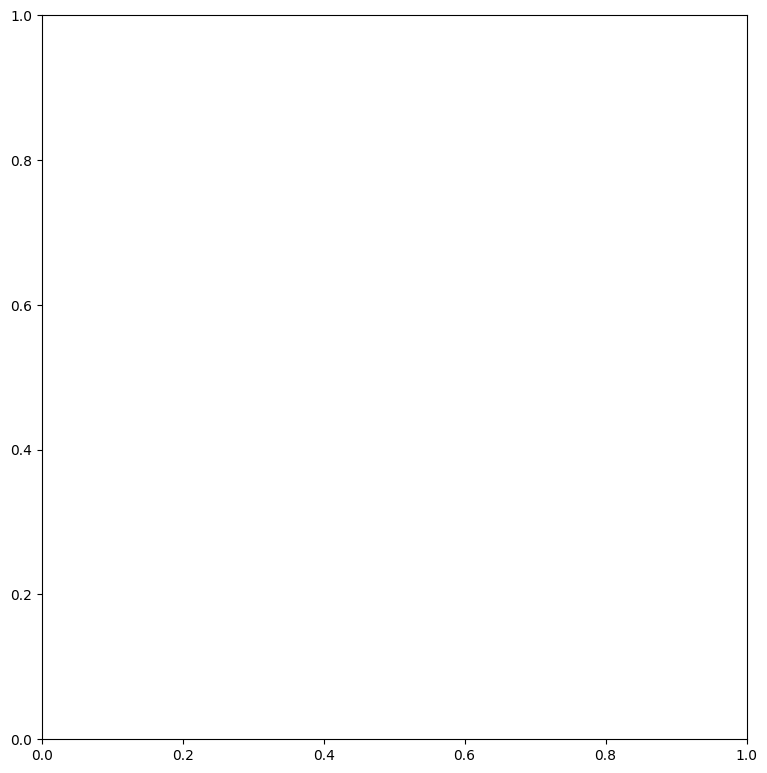

In [3]:
# generating subhalo location and mass vs time gifs!

from matplotlib.animation import FuncAnimation, PillowWriter
from PIL import Image, ImageSequence
import glob
import re

base_dir = "C:/Users/steph/Symphony"
suite_list = ["SymphonyCluster"]
image_directory = "subhalo_gif/*.png"
output_gif_path = "subhalo_animation.gif"

fig, ax = plt.subplots(ncols = 1, nrows = 1, figsize = (8, 8))

for suite_index, suite_name in enumerate(suite_list):
    n_hosts = symlib.n_hosts(suite_name)
    
    for i_host in range(1):
        sim_dir = symlib.get_host_directory(base_dir, suite_name, i_host)
        scale_factors = symlib.scale_factors(sim_dir)
        h, hist = symlib.read_subhalos(sim_dir)

        for snap_index, snap in enumerate(scale_factors):
            host = h[0, snap_index]
            symlib.plot_circle(ax, host["x"][0], host["x"][1], host["rvir"], c = "tab:red")
            
            z0_radius = 100
        
            for i in range(1, len(h)):
                sub = h[i, snap_index]
                if sub["ok"]:
                    symlib.plot_circle(ax, sub['x'][0], sub['x'][1], sub['rvir'], c = "tab:blue", lw = 1.5)

            ax.set_xlim(-7*host["rvir"], 7*host["rvir"])
            ax.set_ylim(-7*host["rvir"], 7*host["rvir"])                            
            #ax.set_xlim(-3000, 3000)
            #ax.set_ylim(-3000, 3000)
            
            ax.set_title(f'a = {(snap):2f}')
            plt.tight_layout()
            
            output_directory = "subhalo_gif"
            filename = f"subhalo_image_{snap_index}.png"
            
            if not os.path.exists(output_directory):
                os.makedirs(output_directory)
                
            full_path = os.path.join(output_directory, filename)
            plt.savefig(full_path, dpi = 100, facecolor = 'white')

            if snap_index < len(scale_factors):
                print(snap_index + 1, len(scale_factors))
                ax.clear()

In [4]:
from matplotlib.animation import FuncAnimation, PillowWriter
from PIL import Image, ImageSequence
import glob
import re

image_directory = "subhalo_gif/*.png"
output_gif_path = "subhalo_animation.gif"

image_paths = glob.glob(image_directory)
image_paths = sorted(glob.glob(image_directory), key=lambda x: int(re.search(r"(\d+)", x).group()))
 
# Load images 
images = []
for path in image_paths:
    img = Image.open(path)
    images.append(img)

if images:
    images[0].save(output_gif_path, save_all=True, append_images=images[1:], duration = 75, loop=0)
    print(f"GIF created and saved at {output_gif_path}")
else:
    print("No images found in the specified directory.")

GIF created and saved at subhalo_animation.gif
